# 08 — Explainability

This notebook explains and audits the **frozen Fold 3 production model**.

It does **not**:

* retrain the model
* tune hyperparameters
* change regime thresholds
* change service levels
* change inventory policies
* select a new model
* modify Fold 3 evaluation results

The production model is the exact artifact produced in Notebook 07:

`tweedie_optimized_fold3.txt`

Fold 3 remains the final untouched evaluation set. Notebook 08 only analyzes the already-frozen model and its predictions.

## Production architecture

| Demand regime | Forecast method   | Explainability               |
| ------------- | ----------------- | ---------------------------- |
| Smooth        | LightGBM Tweedie  | SHAP                         |
| Erratic       | LightGBM Tweedie  | SHAP                         |
| Intermittent  | TSB               | Routing / policy explanation |
| Lumpy         | Historical policy | Routing / policy explanation |

SHAP is only applicable to Smooth and Erratic SKUs because those are the regimes actually using the LightGBM Tweedie model.

## Goals

The purpose of this notebook is to answer four questions:

1. **What features drive the production model globally?**
2. **Do the important features change by demand regime?**
3. **Are the model's drivers stable across departments?**
4. **Can the application explain an individual SKU's forecast?**

The outputs from this notebook are designed to support both the portfolio analysis and the Streamlit application.

## Frozen inputs

* `tweedie_optimized_fold3.txt`
* `feature_cols_v2.pkl`
* `sku_regimes_fold3.parquet`
* `features_val_v2.parquet`
* relevant Fold 3 SKU metadata

## Outputs

* `shap_global_fold3.parquet`
* `shap_by_regime_fold3.parquet`
* `shap_by_department_fold3.parquet`
* `shap_per_sku_fold3.parquet`
* `shap_validation_report.json`
* representative SHAP plots for the portfolio

**No output from this notebook is used to change the production model.**


# Section 1 — SHAP Global Importance

This section measures which production features contribute most to the frozen Fold 3 Tweedie forecasts.

SHAP values are calculated only for Smooth and Erratic SKUs because these are the populations routed to LightGBM Tweedie.

The global importance measure is:

> **mean absolute SHAP value**

A larger value means the feature has a larger average contribution to the model's prediction magnitude.

The analysis uses a fixed, reproducible sample of the Fold 3 validation population. Sampling is proportional to the actual Smooth/Erratic population rather than forcing equal representation across regimes.

### Questions

* Which features dominate the production model?
* Are the top features consistent with the feature-engineering design?
* Are any unexpected features disproportionately influential?
* Are there potential leakage or proxy features that require investigation?

This is an explainability analysis only. No model or feature set is changed based on the results.


── Notebook 08: Explainability ──
Read-only analysis of the frozen Fold 3 production model.

Model loaded: ../data/processed/models/tweedie_optimized_fold3.txt
Feature count: 39
Fold 3 validation rows: 11,128,850

✓ Model feature names/order match frozen feature_cols_v2.pkl.
✓ Fold 3 validation contains all production features.

SHAP population:
regime
erratic     330690
smooth     2960515
Name: count, dtype: int64
Total Tweedie-routed validation rows: 3,291,205

Using SHAP sample: 50,000 rows
regime
erratic     5024
smooth     44976
Name: count, dtype: int64

Computing TreeSHAP values...
SHAP matrix: (50000, 39)

── SHAP reconstruction check ──
Base value: -0.513397
Mean absolute reconstruction error: 2.0887691522
Max absolute reconstruction error: 147.6595597531

Saved: ../data/processed/predictions/explainability/shap_global_fold3.parquet

── Top 20 Global SHAP Features ──
           feature  mean_abs_shap  mean_signed_shap  rank
   rolling_mean_28       0.521124          0.149303  

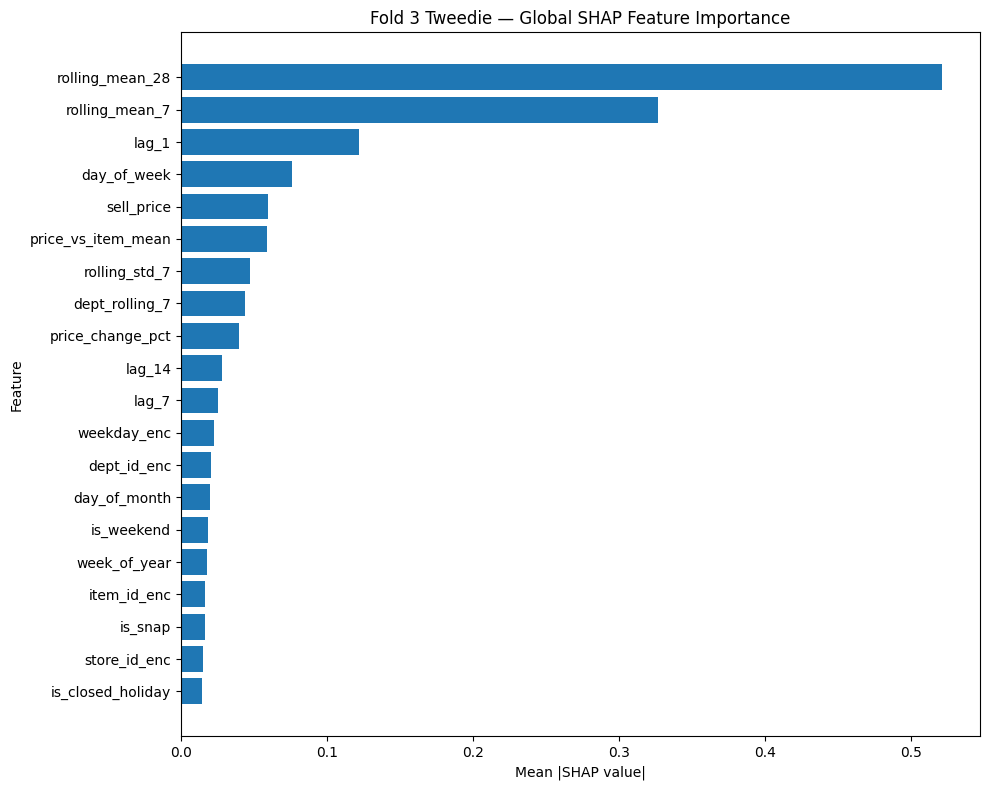

Saved: ../data/processed/predictions/explainability/shap_global_importance_fold3.png

✓ Section 1 complete.
✓ Frozen model unchanged.
✓ No model selection or tuning performed.


In [1]:
# -- 08 Section 1: SHAP Global Importance -----------------------------------------------
# Read-only analysis of the frozen Fold 3 production model.
# No retraining, tuning, feature selection, or modification of Fold 3 artifacts.

import os
import json
import pickle
import warnings
import numpy as np
import pandas as pd
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

PROCESSED_DIR    = '../data/processed'
CALIBRATION_DIR  = f'{PROCESSED_DIR}/calibration'
SEGMENTATION_DIR = f'{PROCESSED_DIR}/segmentation'
MODELS_DIR       = f'{PROCESSED_DIR}/models'
PREDICTIONS_DIR  = f'{PROCESSED_DIR}/predictions'
FEATURES_DIR     = f'{PROCESSED_DIR}/features'

SHAP_DIR = f'{PREDICTIONS_DIR}/explainability'
os.makedirs(SHAP_DIR, exist_ok=True)

# Reproducible sampling
SHAP_SEED = 42
MAX_SHAP_ROWS = 50_000

print('── Notebook 08: Explainability ──')
print('Read-only analysis of the frozen Fold 3 production model.')
print()

# ── Required frozen artifacts -----------------------------------------------------------

model_path = f'{MODELS_DIR}/tweedie_optimized_fold3.txt'
feature_cols_path = f'{FEATURES_DIR}/feature_cols_v2.pkl'
regime_path = f'{SEGMENTATION_DIR}/sku_regimes_fold3.parquet'
val_path = f'{FEATURES_DIR}/features_val_v2.parquet'

for path in [
    model_path,
    feature_cols_path,
    regime_path,
    val_path,
]:
    assert os.path.exists(path), f'Missing required frozen artifact: {path}'

# ── Load frozen model -------------------------------------------------------------------

model_tweedie_fold3 = lgb.Booster(
    model_file=model_path
)

with open(feature_cols_path, 'rb') as f:
    FEATURE_COLS = pickle.load(f)

sku_regimes_fold3 = pd.read_parquet(regime_path)
fold3_val = pd.read_parquet(val_path)

fold3_val['date'] = pd.to_datetime(fold3_val['date'])

print(f'Model loaded: {model_path}')
print(f'Feature count: {len(FEATURE_COLS):,}')
print(f'Fold 3 validation rows: {len(fold3_val):,}')
print()

# ── Verify model / feature contract -----------------------------------------------------

model_features = list(model_tweedie_fold3.feature_name())

assert model_features == list(FEATURE_COLS), (
    'CRITICAL: frozen model feature order does not exactly match '
    'feature_cols_v2.pkl.'
)

missing_features = [
    c for c in FEATURE_COLS
    if c not in fold3_val.columns
]

assert not missing_features, (
    f'Fold 3 validation data is missing {len(missing_features)} '
    f'production feature(s): {missing_features[:10]}'
)

assert sku_regimes_fold3['id'].is_unique, (
    'sku_regimes_fold3 contains duplicate SKU ids.'
)

print('✓ Model feature names/order match frozen feature_cols_v2.pkl.')
print('✓ Fold 3 validation contains all production features.')
print()

# ── Restrict to Tweedie production population ------------------------------------------

regime_lookup = (
    sku_regimes_fold3
    .set_index('id')['regime']
)

tweedie_ids = set(
    sku_regimes_fold3.loc[
        sku_regimes_fold3['regime'].isin(['smooth', 'erratic']),
        'id'
    ]
)

shap_population = fold3_val[
    fold3_val['id'].isin(tweedie_ids)
].copy()

assert set(
    shap_population['id'].unique()
).issubset(tweedie_ids)

shap_population['regime'] = (
    shap_population['id'].map(regime_lookup)
)

print('SHAP population:')
print(
    shap_population['regime']
    .value_counts()
    .sort_index()
)
print(
    f'Total Tweedie-routed validation rows: '
    f'{len(shap_population):,}'
)
print()

# ── Fixed reproducible sample -----------------------------------------------------------
#
# Global importance should reflect the actual Smooth/Erratic population.
# Sample proportional to the observed row population instead of forcing equal
# representation across regimes.

rng = np.random.default_rng(SHAP_SEED)

if len(shap_population) > MAX_SHAP_ROWS:

    sampled_parts = []

    regime_counts = (
        shap_population['regime']
        .value_counts()
    )

    for regime, n_regime in regime_counts.items():

        target_n = int(
            round(
                MAX_SHAP_ROWS
                * n_regime
                / len(shap_population)
            )
        )

        target_n = min(
            target_n,
            n_regime
        )

        regime_df = shap_population[
            shap_population['regime'] == regime
        ]

        idx = rng.choice(
            regime_df.index.to_numpy(),
            size=target_n,
            replace=False
        )

        sampled_parts.append(
            regime_df.loc[idx]
        )

    shap_sample = (
        pd.concat(sampled_parts)
        .sample(
            frac=1.0,
            random_state=SHAP_SEED
        )
        .reset_index(drop=True)
    )

else:
    shap_sample = shap_population.copy()

print(
    f'Using SHAP sample: '
    f'{len(shap_sample):,} rows'
)
print(
    shap_sample['regime']
    .value_counts()
    .sort_index()
)
print()

# ── Build model matrix ------------------------------------------------------------------

X_shap = shap_sample[FEATURE_COLS].copy()

# Ensure LightGBM receives the same feature order and compatible column names.
X_shap = X_shap[model_features]

# ── SHAP calculation --------------------------------------------------------------------

print('Computing TreeSHAP values...')

explainer = shap.TreeExplainer(
    model_tweedie_fold3
)

shap_values = explainer.shap_values(X_shap)

# LightGBM regression returns an array; guard against unexpected list output.
if isinstance(shap_values, list):
    assert len(shap_values) == 1, (
        f'Unexpected SHAP output structure: {len(shap_values)} arrays.'
    )
    shap_values = shap_values[0]

shap_values = np.asarray(shap_values)

assert shap_values.shape == X_shap.shape, (
    f'SHAP shape {shap_values.shape} does not match '
    f'feature matrix shape {X_shap.shape}.'
)

print(f'SHAP matrix: {shap_values.shape}')
print()

# ── Global importance -------------------------------------------------------------------

global_importance = pd.DataFrame({
    'feature': FEATURE_COLS,
    'mean_abs_shap': np.mean(
        np.abs(shap_values),
        axis=0
    ),
    'mean_signed_shap': np.mean(
        shap_values,
        axis=0
    ),
})

global_importance['rank'] = (
    global_importance['mean_abs_shap']
    .rank(
        ascending=False,
        method='min'
    )
    .astype(int)
)

global_importance = (
    global_importance
    .sort_values(
        ['mean_abs_shap', 'feature'],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

# ── SHAP reconstruction sanity check ----------------------------------------------------

model_output = model_tweedie_fold3.predict(
    X_shap
)

base_value = explainer.expected_value

if np.ndim(base_value) > 0:
    base_value = float(np.asarray(base_value).reshape(-1)[0])
else:
    base_value = float(base_value)

reconstructed = (
    base_value
    + shap_values.sum(axis=1)
)

reconstruction_error = np.abs(
    reconstructed - model_output
)

print('── SHAP reconstruction check ──')
print(
    f'Base value: {base_value:.6f}'
)
print(
    f'Mean absolute reconstruction error: '
    f'{reconstruction_error.mean():.10f}'
)
print(
    f'Max absolute reconstruction error: '
    f'{reconstruction_error.max():.10f}'
)
print()

# ── Save global artifact ----------------------------------------------------------------

global_path = f'{SHAP_DIR}/shap_global_fold3.parquet'

global_importance.to_parquet(
    global_path,
    index=False
)

print(f'Saved: {global_path}')
print()

# ── Display top features ----------------------------------------------------------------

print('── Top 20 Global SHAP Features ──')
print(
    global_importance
    .head(20)
    .round(6)
    .to_string(index=False)
)

# ── Plot -------------------------------------------------------------------------------

top_n = 20

plot_df = (
    global_importance
    .head(top_n)
    .sort_values('mean_abs_shap')
)

plt.figure(figsize=(10, 8))
plt.barh(
    plot_df['feature'],
    plot_df['mean_abs_shap']
)
plt.xlabel('Mean |SHAP value|')
plt.ylabel('Feature')
plt.title('Fold 3 Tweedie — Global SHAP Feature Importance')
plt.tight_layout()

global_plot_path = (
    f'{SHAP_DIR}/shap_global_importance_fold3.png'
)

plt.savefig(
    global_plot_path,
    dpi=180,
    bbox_inches='tight'
)

plt.show()

print(f'Saved: {global_plot_path}')

print()
print('✓ Section 1 complete.')
print('✓ Frozen model unchanged.')
print('✓ No model selection or tuning performed.')

In [2]:
# -- SHAP scale diagnostic ---------------------------------------------------------------

X_check = X_shap.iloc[:500].copy()

shap_check = explainer.shap_values(X_check)

if isinstance(shap_check, list):
    shap_check = shap_check[0]

shap_check = np.asarray(shap_check)

expected = explainer.expected_value
if np.ndim(expected) > 0:
    expected = float(np.asarray(expected).reshape(-1)[0])
else:
    expected = float(expected)

model_pred_transformed = model_tweedie_fold3.predict(
    X_check
)

model_pred_raw = model_tweedie_fold3.predict(
    X_check,
    raw_score=True
)

reconstructed_raw = (
    expected + shap_check.sum(axis=1)
)

print("Expected SHAP base value:", expected)
print(
    "Raw prediction mean:",
    model_pred_raw.mean()
)
print(
    "Reconstructed SHAP mean:",
    reconstructed_raw.mean()
)
print(
    "Raw-scale MAE:",
    np.mean(
        np.abs(
            reconstructed_raw - model_pred_raw
        )
    )
)
print(
    "Raw-scale max error:",
    np.max(
        np.abs(
            reconstructed_raw - model_pred_raw
        )
    )
)
print(
    "Transformed prediction mean:",
    model_pred_transformed.mean()
)

Expected SHAP base value: -0.51339683227374
Raw prediction mean: 0.03271799442453272
Reconstructed SHAP mean: 0.03271799442453408
Raw-scale MAE: 1.2632964769762611e-14
Raw-scale max error: 9.547918011776346e-14
Transformed prediction mean: 1.946402491431582


## Section 1 — SHAP Global Importance

### Objective

This section explains the **frozen Fold 3 LightGBM Tweedie production model** using TreeSHAP.

The analysis is restricted to the **Smooth and Erratic SKU populations**, because these are the regimes routed to the Tweedie model. Intermittent and Lumpy SKUs use separate production methods and are analyzed through routing/policy explanations in later sections.

No model training, feature selection, hyperparameter tuning, or policy modification occurs here.

### Population and computation

The Fold 3 validation set contains **11,128,850 rows** across the full SKU population. Of these, **3,291,205 rows** belong to Tweedie-routed SKUs:

| Regime    | Validation rows | SHAP sample |
| --------- | --------------: | ----------: |
| Smooth    |       2,960,515 |      44,976 |
| Erratic   |         330,690 |       5,024 |
| **Total** |   **3,291,205** |  **50,000** |

A fixed random seed (`42`) was used to draw the 50,000-row SHAP sample proportionally to the actual Smooth/Erratic population.

The frozen production model contains **39 features**.

### SHAP validation

SHAP reconstruction was explicitly checked on a separate 500-row diagnostic sample.

SHAP reconstructs the LightGBM model's **native raw prediction scale**, not the transformed prediction returned by the standard `predict()` call for this Tweedie model.

The reconstruction results were effectively exact:

| Check                              |         Result |
| ---------------------------------- | -------------: |
| Mean absolute reconstruction error | `1.26 × 10⁻¹⁴` |
| Maximum reconstruction error       | `9.55 × 10⁻¹⁴` |

These errors are at floating-point precision and confirm that the SHAP values correctly decompose the frozen model output.

### Global feature importance

Feature importance is measured using **mean absolute SHAP value**, which captures the average magnitude of each feature's contribution regardless of direction.

The top features are:

| Rank | Feature              | Mean |SHAP| |
| ---: | -------------------- | ----------: |
|    1 | `rolling_mean_28`    |      0.5211 |
|    2 | `rolling_mean_7`     |      0.3268 |
|    3 | `lag_1`              |      0.1219 |
|    4 | `day_of_week`        |      0.0760 |
|    5 | `sell_price`         |      0.0596 |
|    6 | `price_vs_item_mean` |      0.0587 |
|    7 | `rolling_std_7`      |      0.0475 |
|    8 | `dept_rolling_7`     |      0.0438 |
|    9 | `price_change_pct`   |      0.0395 |
|   10 | `lag_14`             |      0.0278 |

The remaining important features include `lag_7`, `weekday_enc`, `dept_id_enc`, `day_of_month`, `is_weekend`, `week_of_year`, `item_id_enc`, `is_snap`, `store_id_enc`, and `is_closed_holiday`.

### Interpretation

The final model learns a coherent retail-demand hierarchy.

**Recent demand level is the dominant signal.** `rolling_mean_28` is the strongest feature, followed by `rolling_mean_7` and `lag_1`. This indicates that the Tweedie model is primarily grounding forecasts in observed SKU-level demand rather than relying on calendar or categorical information alone.

The combination of the 28-day and 7-day rolling means is particularly informative. The model is using both a **longer-term demand baseline** and a **more recent demand state**, while `lag_1` provides the most immediate temporal signal.

**Weekly seasonality is important but secondary to recent demand.** `day_of_week` ranks fourth, showing that recurring weekly demand patterns contribute materially to the forecast without dominating the model.

**Price information is strongly represented.** `sell_price`, `price_vs_item_mean`, and `price_change_pct` all appear in the top 10. This is important because the v2 feature set does not treat price as a single absolute level: it also provides the model with information about the product's position relative to its normal price and its recent price movement.

`price_vs_item_mean` being the sixth-most-important feature is particularly notable because it provides a more product-specific representation of price state than absolute price alone.

**Short-term volatility and cross-SKU context also matter.** `rolling_std_7` and `dept_rolling_7` are both highly ranked, indicating that the model uses recent demand variability and broader department-level demand context in addition to the SKU's own recent history.

### Comparison with the earlier XGBoost diagnostics

The global SHAP hierarchy is broadly consistent with the model-review findings from 05b.

The strongest features remain concentrated in recent demand history:

* `rolling_mean_7`: #1 in the earlier XGBoost SHAP analysis → #2 in the final Tweedie model
* `rolling_mean_28`: #2 → **#1**
* `lag_1`: #3 → **#3**

This stability is important: the final model's dominant signals are not arbitrary consequences of the LightGBM architecture. They reflect persistent demand structure already identified during the earlier diagnostic work.

The final model also places greater emphasis on the engineered price representation:

* `sell_price`: #8 in the earlier XGBoost SHAP analysis → **#5**
* `price_vs_item_mean`: **#6** in the final model
* `price_change_pct`: **#9** in the final model

This supports the broader feature-engineering conclusion that relative and dynamic price information adds useful predictive context beyond absolute price.

The models are not directly comparable by raw SHAP magnitude because they use different objectives and prediction scales, so the comparison is based primarily on **feature ranking and relative importance**, not absolute SHAP values.

### What this does and does not establish

The SHAP results provide evidence about **predictive contribution**, not causality.

For example, the importance of `sell_price` means price information contributes to the model's forecasts; it does not establish a causal price elasticity.

Likewise, the near-zero global signed SHAP value of some calendar features does not mean those features are useless. Effects may vary across SKU, regime, department, or time period and can cancel out when averaged globally.

Those heterogeneous effects are examined in the subsequent regime, department, and feature-dependence analyses.

### Section 1 conclusion

The frozen Fold 3 Tweedie model is using a feature hierarchy that is consistent with the project's earlier EDA and model diagnostics:

> **recent demand level → recent demand state → immediate lag → weekly seasonality → price state → volatility/context**

The stability of the top demand-history features from the earlier XGBoost analysis to the final Tweedie model provides evidence that the production model is learning persistent demand structure rather than relying on a handful of model-specific artifacts.

The strongest v2-era additions visible in the final model are the **relative-price, price-change, volatility, and department-context features**, which now appear among the model's highest-contributing predictors.

**Status: COMPLETE.**

Saved artifact:

`../data/processed/predictions/explainability/shap_global_fold3.parquet`


## Section 2 — SHAP by Demand Regime

Compare SHAP feature importance for the two regimes that use the Tweedie model:

* **Smooth**
* **Erratic**

Importance is measured by mean absolute SHAP value using the same frozen-model SHAP sample from Section 1.

### Questions

* Which features remain important across both regimes?
* Which features change most in relative importance?
* Does Erratic demand rely more heavily on short-term volatility or recent demand state?

Intermittent and Lumpy SKUs are excluded because they use TSB and the historical policy rather than Tweedie.

No model or feature changes are made from this analysis.

**Output:** `shap_by_regime_fold3.parquet`


SECTION 2: SHAP BY DEMAND REGIME

Reusing Section 1 SHAP matrix: 50,000 rows × 39 features.

── SMOOTH ──
           feature  mean_abs_shap  importance_share  mean_signed_shap  global_rank  rank_delta_vs_global
   rolling_mean_28       0.518396          0.327657          0.153550            1                     0
    rolling_mean_7       0.322615          0.203912          0.088881            2                     0
             lag_1       0.120783          0.076342          0.000235            3                     0
       day_of_week       0.076378          0.048275          0.000230            4                     0
price_vs_item_mean       0.058199          0.036785          0.058116            6                     1
        sell_price       0.055897          0.035330          0.049785            5                    -1
     rolling_std_7       0.046801          0.029581          0.013305            7                     0
    dept_rolling_7       0.043131          0.027261   

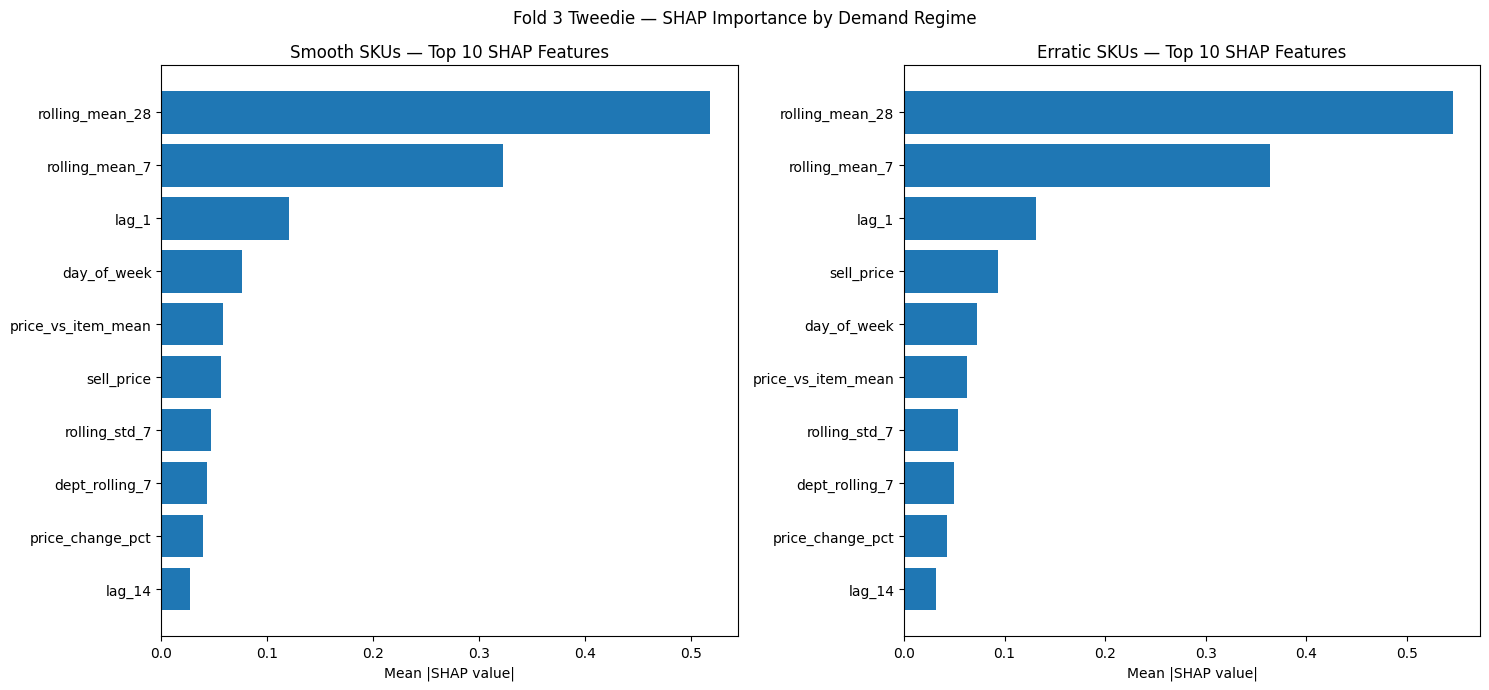

Saved: ../data/processed/predictions/explainability/shap_by_regime_fold3.png

✓ Section 2 complete.
✓ No additional TreeSHAP calculation performed.
✓ Frozen production model unchanged.


<Figure size 640x480 with 0 Axes>

In [3]:
# -- 08 Section 2: SHAP by Demand Regime -----------------------------------------------
# Reuses the exact SHAP matrix and sample generated in Section 1.
# NO new TreeSHAP calculation is performed here.

print('=' * 88)
print('SECTION 2: SHAP BY DEMAND REGIME')
print('=' * 88)
print()

# ── Confirm Section 1 state -------------------------------------------------------------

assert 'shap_values' in globals(), (
    'shap_values is missing. Run Section 1 first.'
)

assert 'shap_sample' in globals(), (
    'shap_sample is missing. Run Section 1 first.'
)

assert 'global_importance' in globals(), (
    'global_importance is missing. Run Section 1 first.'
)

assert shap_values.shape == (
    len(shap_sample),
    len(FEATURE_COLS)
), (
    f'SHAP matrix shape {shap_values.shape} does not match '
    f'SHAP sample/features.'
)

assert set(shap_sample['regime'].dropna().unique()) == {
    'smooth',
    'erratic'
}, (
    'Unexpected regimes in SHAP sample.'
)

print(
    f'Reusing Section 1 SHAP matrix: '
    f'{shap_values.shape[0]:,} rows × '
    f'{shap_values.shape[1]:,} features.'
)
print()

# ── Compute regime-specific importance -------------------------------------------------

regime_rows = []

for regime in ['smooth', 'erratic']:

    mask = (
        shap_sample['regime'].to_numpy()
        == regime
    )

    n_rows = int(mask.sum())

    assert n_rows > 0, (
        f'No SHAP rows available for regime={regime}.'
    )

    regime_shap = shap_values[mask]

    mean_abs = np.mean(
        np.abs(regime_shap),
        axis=0
    )

    mean_signed = np.mean(
        regime_shap,
        axis=0
    )

    total_abs = mean_abs.sum()

    importance_share = (
        mean_abs / total_abs
        if total_abs > 0
        else np.zeros_like(mean_abs)
    )

    for j, feature in enumerate(FEATURE_COLS):

        regime_rows.append({
            'regime': regime,
            'feature': feature,
            'n_rows': n_rows,
            'mean_abs_shap': float(mean_abs[j]),
            'mean_signed_shap': float(mean_signed[j]),
            'importance_share': float(
                importance_share[j]
            ),
        })

shap_regime = pd.DataFrame(regime_rows)

# ── Add regime-specific rank ------------------------------------------------------------

shap_regime['rank'] = (
    shap_regime
    .groupby('regime')['mean_abs_shap']
    .rank(
        ascending=False,
        method='min'
    )
    .astype(int)
)

# ── Add global rank ---------------------------------------------------------------------

global_rank_map = (
    global_importance
    .set_index('feature')['rank']
    .to_dict()
)

shap_regime['global_rank'] = (
    shap_regime['feature']
    .map(global_rank_map)
    .astype(int)
)

shap_regime['rank_delta_vs_global'] = (
    shap_regime['global_rank']
    - shap_regime['rank']
)

shap_regime = (
    shap_regime
    .sort_values(
        ['regime', 'rank']
    )
    .reset_index(drop=True)
)

# ── Top features by regime --------------------------------------------------------------

for regime in ['smooth', 'erratic']:

    print(f'── {regime.upper()} ──')

    display_cols = [
        'feature',
        'mean_abs_shap',
        'importance_share',
        'mean_signed_shap',
        'global_rank',
        'rank_delta_vs_global',
    ]

    print(
        shap_regime[
            shap_regime['regime'] == regime
        ][display_cols]
        .head(15)
        .round(6)
        .to_string(index=False)
    )

    print()

# ── Build side-by-side ranking table ----------------------------------------------------

rank_table = (
    shap_regime
    .pivot(
        index='feature',
        columns='regime',
        values='rank'
    )
    .reset_index()
)

importance_table = (
    shap_regime
    .pivot(
        index='feature',
        columns='regime',
        values='mean_abs_shap'
    )
    .reset_index()
)

share_table = (
    shap_regime
    .pivot(
        index='feature',
        columns='regime',
        values='importance_share'
    )
    .reset_index()
)

rank_table.columns.name = None
importance_table.columns.name = None
share_table.columns.name = None

rank_table = rank_table.rename(
    columns={
        'smooth': 'smooth_rank',
        'erratic': 'erratic_rank',
    }
)

importance_table = importance_table.rename(
    columns={
        'smooth': 'smooth_mean_abs_shap',
        'erratic': 'erratic_mean_abs_shap',
    }
)

share_table = share_table.rename(
    columns={
        'smooth': 'smooth_importance_share',
        'erratic': 'erratic_importance_share',
    }
)

regime_comparison = (
    rank_table
    .merge(
        importance_table,
        on='feature',
        how='inner'
    )
    .merge(
        share_table,
        on='feature',
        how='inner'
    )
)

regime_comparison['rank_difference'] = (
    regime_comparison['smooth_rank']
    - regime_comparison['erratic_rank']
)

# ── Rank correlation --------------------------------------------------------------------

smooth_rank_series = (
    shap_regime[
        shap_regime['regime'] == 'smooth'
    ]
    .set_index('feature')['mean_abs_shap']
)

erratic_rank_series = (
    shap_regime[
        shap_regime['regime'] == 'erratic'
    ]
    .set_index('feature')['mean_abs_shap']
)

rank_corr = (
    smooth_rank_series
    .rank(ascending=False)
    .corr(
        erratic_rank_series
        .rank(ascending=False),
        method='spearman'
    )
)

print('── Regime rank comparison ──')
print(
    f'Spearman rank correlation '
    f'(Smooth vs Erratic): {rank_corr:.4f}'
)
print()

# ── Largest regime-specific differences ------------------------------------------------

regime_diff = (
    shap_regime
    .pivot(
        index='feature',
        columns='regime',
        values='importance_share'
    )
    .reset_index()
)

regime_diff['abs_share_difference'] = (
    regime_diff['smooth']
    - regime_diff['erratic']
).abs()

regime_diff = (
    regime_diff
    .sort_values(
        'abs_share_difference',
        ascending=False
    )
)

print('── Largest regime differences by normalized importance ──')
print(
    regime_diff
    .head(15)
    .round(6)
    .to_string(index=False)
)
print()

# ── Save primary artifact ---------------------------------------------------------------

regime_path = (
    f'{SHAP_DIR}/shap_by_regime_fold3.parquet'
)

shap_regime.to_parquet(
    regime_path,
    index=False
)

print(
    f'Saved: {regime_path}'
)

# ── Save comparison table for easier downstream/app use --------------------------------

comparison_path = (
    f'{SHAP_DIR}/shap_regime_comparison_fold3.parquet'
)

regime_comparison.to_parquet(
    comparison_path,
    index=False
)

print(
    f'Saved: {comparison_path}'
)

# ── Plot: top 10 features by regime -----------------------------------------------------

top_n = 10

smooth_top = (
    shap_regime[
        shap_regime['regime'] == 'smooth'
    ]
    .nsmallest(top_n, 'rank')
)

erratic_top = (
    shap_regime[
        shap_regime['regime'] == 'erratic'
    ]
    .nsmallest(top_n, 'rank')
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 7)
)

smooth_plot = (
    smooth_top
    .sort_values('mean_abs_shap')
)

axes[0].barh(
    smooth_plot['feature'],
    smooth_plot['mean_abs_shap']
)

axes[0].set_title(
    'Smooth SKUs — Top 10 SHAP Features'
)

axes[0].set_xlabel(
    'Mean |SHAP value|'
)

erratic_plot = (
    erratic_top
    .sort_values('mean_abs_shap')
)

axes[1].barh(
    erratic_plot['feature'],
    erratic_plot['mean_abs_shap']
)

axes[1].set_title(
    'Erratic SKUs — Top 10 SHAP Features'
)

axes[1].set_xlabel(
    'Mean |SHAP value|'
)

plt.suptitle(
    'Fold 3 Tweedie — SHAP Importance by Demand Regime'
)

plt.tight_layout()
plt.show()

plot_path = (
    f'{SHAP_DIR}/shap_by_regime_fold3.png'
)

plt.savefig(
    plot_path,
    dpi=180,
    bbox_inches='tight'
)

print(
    f'Saved: {plot_path}'
)

print()
print('✓ Section 2 complete.')
print('✓ No additional TreeSHAP calculation performed.')
print('✓ Frozen production model unchanged.')

## Section 2 Findings — SHAP by Demand Regime

Feature importance is highly consistent between Smooth and Erratic SKUs, with a **Spearman rank correlation of 0.994**.

Both regimes are dominated by the same core signals:

1. `rolling_mean_28`
2. `rolling_mean_7`
3. `lag_1`
4. `day_of_week`
5. price-related features
6. short-term volatility and department context

The main difference is **price importance**: `sell_price` contributes more for Erratic SKUs (5.3% of total SHAP importance) than Smooth SKUs (3.5%), while `rolling_mean_28` is relatively more dominant for Smooth demand.

This indicates that the model's core demand structure is stable across regimes, with Erratic SKUs placing somewhat greater reliance on price information rather than using an entirely different feature hierarchy.

**Conclusion:** Demand regime changes the relative strength of features more than it changes the underlying drivers of the Tweedie model.

Saved: `shap_by_regime_fold3.parquet`


## Section 3 — SHAP by Department

Compare SHAP feature importance across the three major departments:

* **FOODS**
* **HOBBIES**
* **HOUSEHOLD**

Use the existing Section 1 SHAP sample and frozen Fold 3 model.

### Questions

* Are the top demand drivers consistent across departments?
* Which features vary most by department?
* Does product context materially change the model's feature hierarchy?

Importance is measured using mean absolute SHAP value and compared using feature ranks and normalized importance.

No model or feature changes are made from this analysis.

**Output:** `shap_by_department_fold3.parquet`


SECTION 3: SHAP BY DEPARTMENT

SHAP sample by major department:
department
FOODS        26651
HOBBIES       7800
HOUSEHOLD    15549
Name: count, dtype: int64

── FOODS ──
           feature  mean_abs_shap  importance_share  global_rank  rank_delta_vs_global
   rolling_mean_28       0.545846          0.312775            1                     0
    rolling_mean_7       0.400119          0.229272            2                     0
             lag_1       0.138477          0.079349            3                     0
       day_of_week       0.069948          0.040081            4                     0
        sell_price       0.061027          0.034969            5                     0
     rolling_std_7       0.054878          0.031446            7                     1
price_vs_item_mean       0.051856          0.029714            6                    -1
    dept_rolling_7       0.044690          0.025608            8                     0
  price_change_pct       0.040691          0.0

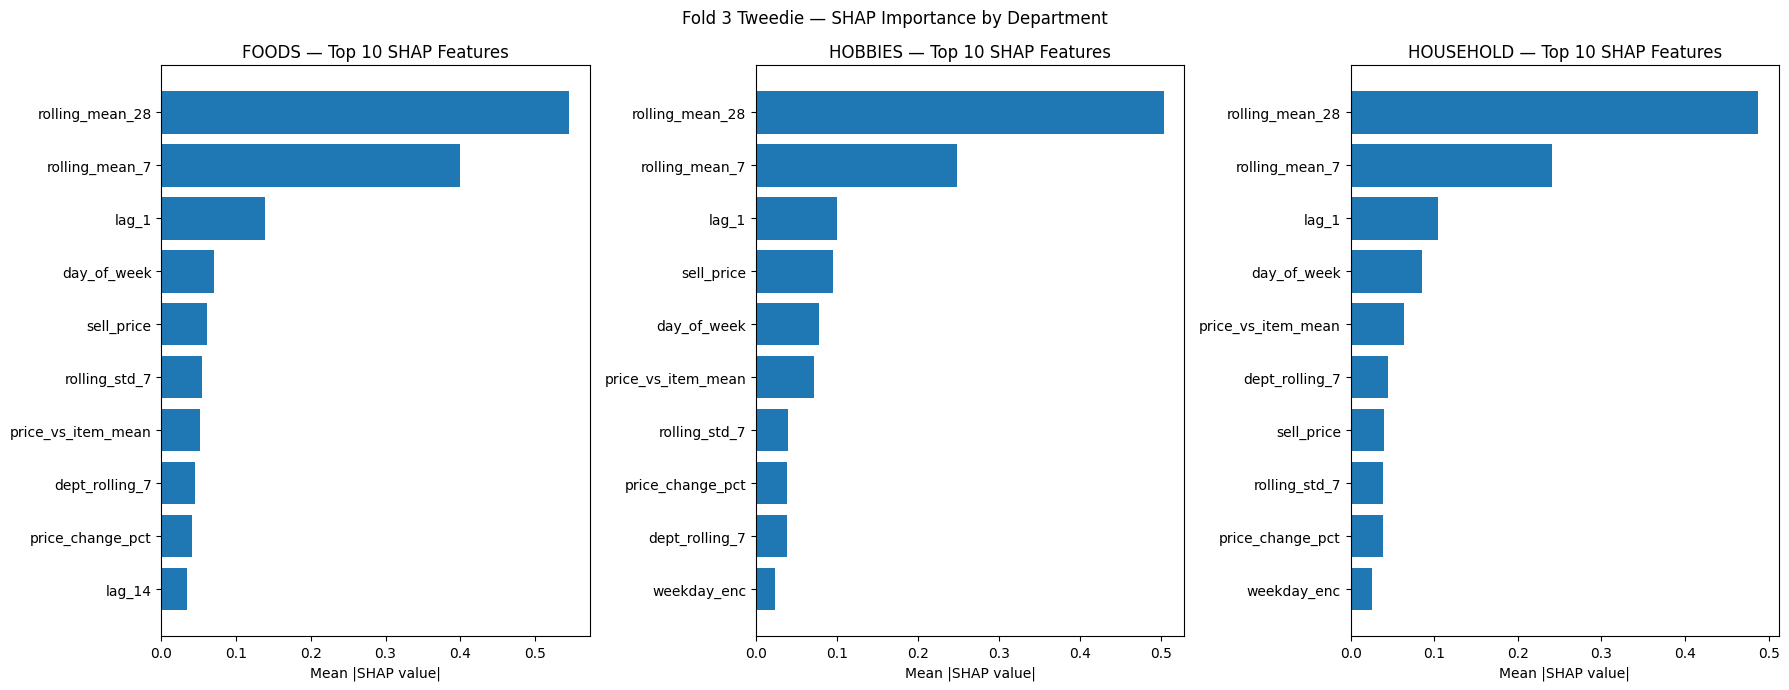

Saved: ../data/processed/predictions/explainability/shap_by_department_fold3.png

✓ Section 3 complete.
✓ No additional TreeSHAP calculation performed.
✓ Frozen production model unchanged.


<Figure size 640x480 with 0 Axes>

In [4]:
# -- 08 Section 3: SHAP by Department -----------------------------------------------
# Reuses the exact SHAP matrix/sample from Section 1.
# No additional TreeSHAP computation.

print('=' * 88)
print('SECTION 3: SHAP BY DEPARTMENT')
print('=' * 88)
print()

# ── Required Section 1 state -----------------------------------------------------------

assert 'shap_values' in globals(), 'shap_values is missing. Run Section 1 first.'
assert 'shap_sample' in globals(), 'shap_sample is missing. Run Section 1 first.'

# ── Department mapping ------------------------------------------------------------------
# IDs look like: FOODS_3_163_CA_3
# Department is the first two underscore-separated components.

shap_sample = shap_sample.copy()

shap_sample['dept_id'] = (
    shap_sample['id']
    .str.split('_')
    .str[:2]
    .str.join('_')
)

expected_depts = {'FOODS_1', 'FOODS_2', 'FOODS_3',
                  'HOBBIES_1', 'HOBBIES_2',
                  'HOUSEHOLD_1', 'HOUSEHOLD_2', 'HOUSEHOLD_3'}

# Collapse to major department family for the portfolio comparison.
shap_sample['department'] = (
    shap_sample['dept_id']
    .str.split('_')
    .str[0]
)

major_departments = ['FOODS', 'HOBBIES', 'HOUSEHOLD']

assert set(shap_sample['department']).issubset(
    set(major_departments)
), 'Unexpected department family found.'

print('SHAP sample by major department:')
print(
    shap_sample['department']
    .value_counts()
    .sort_index()
)
print()

# ── Compute importance by department ----------------------------------------------------

department_rows = []

for department in major_departments:

    mask = (
        shap_sample['department'].to_numpy()
        == department
    )

    n_rows = int(mask.sum())

    assert n_rows > 0, (
        f'No SHAP rows available for {department}.'
    )

    dept_shap = shap_values[mask]

    mean_abs = np.mean(
        np.abs(dept_shap),
        axis=0
    )

    mean_signed = np.mean(
        dept_shap,
        axis=0
    )

    total_abs = mean_abs.sum()

    importance_share = (
        mean_abs / total_abs
        if total_abs > 0
        else np.zeros_like(mean_abs)
    )

    for j, feature in enumerate(FEATURE_COLS):

        department_rows.append({
            'department': department,
            'feature': feature,
            'n_rows': n_rows,
            'mean_abs_shap': float(mean_abs[j]),
            'mean_signed_shap': float(mean_signed[j]),
            'importance_share': float(
                importance_share[j]
            ),
        })

shap_department = pd.DataFrame(
    department_rows
)

# ── Rank within department --------------------------------------------------------------

shap_department['rank'] = (
    shap_department
    .groupby('department')['mean_abs_shap']
    .rank(
        ascending=False,
        method='min'
    )
    .astype(int)
)

# ── Global rank from Section 1 ----------------------------------------------------------

global_rank_map = (
    global_importance
    .set_index('feature')['rank']
    .to_dict()
)

shap_department['global_rank'] = (
    shap_department['feature']
    .map(global_rank_map)
    .astype(int)
)

shap_department['rank_delta_vs_global'] = (
    shap_department['global_rank']
    - shap_department['rank']
)

shap_department = (
    shap_department
    .sort_values(
        ['department', 'rank']
    )
    .reset_index(drop=True)
)

# ── Print top 15 per department ---------------------------------------------------------

display_cols = [
    'feature',
    'mean_abs_shap',
    'importance_share',
    'global_rank',
    'rank_delta_vs_global',
]

for department in major_departments:

    print(f'── {department} ──')

    print(
        shap_department[
            shap_department['department'] == department
        ][display_cols]
        .head(15)
        .round(6)
        .to_string(index=False)
    )

    print()

# ── Build rank matrix -------------------------------------------------------------------

rank_table = (
    shap_department
    .pivot(
        index='feature',
        columns='department',
        values='rank'
    )
    .reset_index()
)

rank_table.columns.name = None

# ── Spearman rank correlations ----------------------------------------------------------

rank_pivots = (
    shap_department
    .pivot(
        index='feature',
        columns='department',
        values='mean_abs_shap'
    )
)

print('── Department rank correlations ──')

corr_table = rank_pivots.rank(
    ascending=False
).corr(
    method='spearman'
)

print(
    corr_table.round(4).to_string()
)
print()

# ── Largest department differences ------------------------------------------------------

share_pivot = (
    shap_department
    .pivot(
        index='feature',
        columns='department',
        values='importance_share'
    )
)

share_pivot['max_minus_min'] = (
    share_pivot.max(axis=1)
    - share_pivot.min(axis=1)
)

largest_differences = (
    share_pivot
    .sort_values(
        'max_minus_min',
        ascending=False
    )
)

print('── Largest department differences ──')

print(
    largest_differences
    .head(15)
    .round(6)
    .to_string()
)
print()

# ── Save artifact -----------------------------------------------------------------------

department_path = (
    f'{SHAP_DIR}/shap_by_department_fold3.parquet'
)

shap_department.to_parquet(
    department_path,
    index=False
)

print(
    f'Saved: {department_path}'
)

# ── Plot top 10 by department -----------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 7)
)

for ax, department in zip(
    axes,
    major_departments
):

    top = (
        shap_department[
            shap_department['department'] == department
        ]
        .nsmallest(10, 'rank')
        .sort_values('mean_abs_shap')
    )

    ax.barh(
        top['feature'],
        top['mean_abs_shap']
    )

    ax.set_title(
        f'{department} — Top 10 SHAP Features'
    )

    ax.set_xlabel(
        'Mean |SHAP value|'
    )

plt.suptitle(
    'Fold 3 Tweedie — SHAP Importance by Department'
)

plt.tight_layout()
plt.show()

plot_path = (
    f'{SHAP_DIR}/shap_by_department_fold3.png'
)

plt.savefig(
    plot_path,
    dpi=180,
    bbox_inches='tight'
)

print(
    f'Saved: {plot_path}'
)

print()
print('✓ Section 3 complete.')
print('✓ No additional TreeSHAP calculation performed.')
print('✓ Frozen production model unchanged.')

## Section 3 Findings — SHAP by Department

Feature importance is highly consistent across **FOODS, HOBBIES, and HOUSEHOLD**, with rank correlations of **0.96–0.99**.

All three departments share the same core hierarchy:

1. `rolling_mean_28`
2. `rolling_mean_7`
3. `lag_1`
4. `day_of_week`

The largest department-specific difference is **price importance**. `sell_price` ranks **#4 in HOBBIES** versus #5 in FOODS and #7 in HOUSEHOLD, while `rolling_mean_7` is relatively more important for FOODS.

Overall, department changes the **relative strength** of features more than the underlying feature hierarchy.

**Conclusion:** The frozen Tweedie model learns broadly consistent demand drivers across major product departments rather than relying on department-specific modeling.

Saved: `shap_by_department_fold3.parquet`


## Section 4 — Per-SKU Explainability

Create an app-ready explanation for each Smooth and Erratic SKU using the **latest available Fold 3 validation snapshot**.

For each SKU, retain the five features with the largest absolute SHAP contributions, including feature value and direction.

These results will power the app's **"Why is this forecast changing?"** explanation without running SHAP at runtime.

Intermittent and Lumpy SKUs are excluded because they use TSB and the historical policy rather than the Tweedie model.

**Output:** `shap_per_sku_fold3.parquet`


In [9]:
# -- 08 Section 4: Per-SKU Explainability ----------------------------------------------
# One explanation snapshot per Smooth/Erratic SKU.
# Uses the frozen Fold 3 model. No retraining or model changes.

print('=' * 88)
print('SECTION 4: PER-SKU EXPLAINABILITY')
print('=' * 88)
print()

# ── Required state ----------------------------------------------------------------------

assert 'model_tweedie_fold3' in globals()
assert 'FEATURE_COLS' in globals()
assert 'sku_regimes_fold3' in globals()

# ── Select latest available Fold 3 validation row per Tweedie SKU ----------------------

tweedie_ids = set(
    sku_regimes_fold3.loc[
        sku_regimes_fold3['regime'].isin(['smooth', 'erratic']),
        'id'
    ]
)

regime_lookup = (
    sku_regimes_fold3
    .set_index('id')['regime']
)

sku_snapshot = (
    fold3_val[
        fold3_val['id'].isin(tweedie_ids)
    ]
    .sort_values(['id', 'date'])
    .groupby('id', observed=True)
    .tail(1)
    .copy()
)

assert sku_snapshot['id'].nunique() == len(tweedie_ids), (
    'Some Tweedie-routed SKUs have no Fold 3 validation snapshot.'
)

sku_snapshot['regime'] = (
    sku_snapshot['id'].map(regime_lookup)
)

print(
    f'Tweedie-routed SKUs: {len(tweedie_ids):,}'
)
print(
    f'Snapshot rows: {len(sku_snapshot):,}'
)
print(
    sku_snapshot['regime'].value_counts().sort_index()
)
print()

# ── Compute SHAP for the SKU snapshot ---------------------------------------------------

X_sku = sku_snapshot[FEATURE_COLS].copy()

explainer_sku = shap.TreeExplainer(
    model_tweedie_fold3
)

print('Computing per-SKU SHAP values...')

shap_sku_values = explainer_sku.shap_values(X_sku)

if isinstance(shap_sku_values, list):
    assert len(shap_sku_values) == 1, (
        f'Unexpected SHAP output structure: {len(shap_sku_values)} arrays.'
    )
    shap_sku_values = shap_sku_values[0]

shap_sku_values = np.asarray(shap_sku_values)

assert shap_sku_values.shape == X_sku.shape, (
    f'SHAP shape {shap_sku_values.shape} does not match '
    f'feature matrix shape {X_sku.shape}.'
)

print(
    f'SHAP matrix: {shap_sku_values.shape}'
)
print()

# ── Keep top 5 contributors per SKU -----------------------------------------------------

records = []

for row_idx, sku_id in enumerate(
    sku_snapshot['id'].to_numpy()
):

    shap_row = shap_sku_values[row_idx]
    feature_values = X_sku.iloc[row_idx]

    top_indices = np.argsort(
        np.abs(shap_row)
    )[::-1][:5]

    for rank, feature_idx in enumerate(
        top_indices,
        start=1
    ):

        feature = FEATURE_COLS[feature_idx]
        shap_value = float(shap_row[feature_idx])
        feature_value = feature_values.iloc[feature_idx]

        records.append({
            'id': sku_id,
            'date': sku_snapshot.iloc[row_idx]['date'],
            'regime': sku_snapshot.iloc[row_idx]['regime'],
            'feature': feature,
            'feature_value': feature_value,
            'feature_value_missing': pd.isna(feature_value),
            'shap_value': shap_value,
            'abs_shap': abs(shap_value),
            'direction': (
                'positive'
                if shap_value > 0
                else 'negative'
                if shap_value < 0
                else 'neutral'
            ),
            'rank': rank,
        })

shap_per_sku = pd.DataFrame(records)

# ── Validation --------------------------------------------------------------------------

expected_rows = len(tweedie_ids) * 5

assert len(shap_per_sku) == expected_rows, (
    f'Expected {expected_rows:,} SHAP rows, '
    f'got {len(shap_per_sku):,}.'
)

assert (
    shap_per_sku
    .groupby('id', observed=True)['rank']
    .nunique()
    .eq(5)
    .all()
), (
    'Every Tweedie SKU must have exactly five ranked SHAP features.'
)

# Feature values are allowed to be NaN because the frozen LightGBM feature
# pipeline legitimately contains missing historical/lag values.
# SHAP contributions themselves must always be finite.
assert np.isfinite(
    shap_per_sku['shap_value']
).all(), (
    'BUG: non-finite SHAP contribution detected.'
)

assert np.isfinite(
    shap_per_sku['abs_shap']
).all(), (
    'BUG: non-finite absolute SHAP contribution detected.'
)

assert (
    shap_per_sku['direction']
    .isin(['positive', 'negative', 'neutral'])
    .all()
), (
    'Unexpected SHAP direction value.'
)

# ── Summary of missing feature values ---------------------------------------------------

n_missing_feature_values = int(
    shap_per_sku['feature_value_missing'].sum()
)

n_rows_with_missing = int(
    shap_per_sku['feature_value_missing']
    .groupby(shap_per_sku['id'], observed=True)
    .any()
    .sum()
)

print(
    f'Rows with missing top-feature values: '
    f'{n_missing_feature_values:,}'
)
print(
    f'SKUs with at least one missing top-feature value: '
    f'{n_rows_with_missing:,}'
)
print(
    'Missing feature values are retained as-is; '
    'the frozen LightGBM model supports them.'
)
print()

# ── Save --------------------------------------------------------------------------------

sku_shap_path = (
    f'{SHAP_DIR}/shap_per_sku_fold3.parquet'
)

shap_per_sku.to_parquet(
    sku_shap_path,
    index=False
)

print(
    f'Saved: {sku_shap_path}'
)
print(
    f'Rows: {len(shap_per_sku):,}'
)
print(
    f'SKUs: {shap_per_sku["id"].nunique():,}'
)

# ── Example output ----------------------------------------------------------------------

print('\n── Example SKU explanations ──')

example_ids = (
    shap_per_sku['id']
    .drop_duplicates()
    .head(3)
)

for sku_id in example_ids:

    print(f'\n{sku_id}')

    print(
        shap_per_sku[
            shap_per_sku['id'] == sku_id
        ][
            [
                'feature',
                'feature_value',
                'feature_value_missing',
                'shap_value',
                'direction',
                'rank'
            ]
        ]
        .round(4)
        .to_string(index=False)
    )

print()
print('✓ Section 4 complete.')
print('✓ One explanation snapshot generated per Tweedie-routed SKU.')
print('✓ SHAP contributions validated as finite.')
print('✓ Frozen production model unchanged.')

SECTION 4: PER-SKU EXPLAINABILITY

Tweedie-routed SKUs: 9,017
Snapshot rows: 9,017
regime
erratic     906
smooth     8111
Name: count, dtype: int64

Computing per-SKU SHAP values...
SHAP matrix: (9017, 39)

Rows with missing top-feature values: 2,171
SKUs with at least one missing top-feature value: 553
Missing feature values are retained as-is; the frozen LightGBM model supports them.

Saved: ../data/processed/predictions/explainability/shap_per_sku_fold3.parquet
Rows: 45,085
SKUs: 9,017

── Example SKU explanations ──

FOODS_1_001_CA_1_validation
        feature  feature_value  feature_value_missing  shap_value direction  rank
rolling_mean_28         0.4643                  False     -0.2731  negative     1
    day_of_week         6.0000                  False      0.1104  positive     2
          lag_1         0.0000                  False     -0.0969  negative     3
   store_id_enc         0.0000                  False      0.0654  positive     4
     sell_price         2.2400     

## Section 4 — Per-SKU Explainability

This section generates a compact explanation for the latest Fold 3 validation observation of every Tweedie-routed SKU. SHAP is used only as a **predictive contribution** measure; it is not a causal or elasticity estimate.

### Coverage

| Metric                                 | Result |
| -------------------------------------- | -----: |
| Tweedie-routed SKUs                    |  9,017 |
| Smooth                                 |  8,111 |
| Erratic                                |    906 |
| Features explained                     |     39 |
| Top features retained per SKU          |      5 |
| Explanation records                    | 45,085 |
| SKUs with ≥1 missing top-feature value |    553 |

Missing feature values are retained because they are valid inputs to the frozen LightGBM model. Only SHAP outputs are required to be finite.

### Example SKU Explanations

| SKU                         | Regime | Top contribution |   SHAP | 2nd         |   SHAP | 3rd          |   SHAP |
| --------------------------- | ------ | ---------------- | -----: | ----------- | -----: | ------------ | -----: |
| FOODS_1_001_CA_1_validation | Smooth | rolling_mean_28  | -0.273 | day_of_week | +0.110 | lag_1        | -0.097 |
| FOODS_1_001_CA_2_validation | Smooth | rolling_mean_28  | +0.247 | day_of_week | +0.114 | store_id_enc | +0.075 |
| FOODS_1_001_CA_3_validation | Smooth | rolling_mean_28  | +0.194 | lag_1       | -0.124 | day_of_week  | +0.096 |

Positive SHAP values push the model's prediction upward on the native prediction scale; negative values push it downward.

The resulting `shap_per_sku_fold3.parquet` provides the app with precomputed SKU-level explanations, so Streamlit does not need to run SHAP interactively.


## Section 5 — Representative Explainability Cases

This section demonstrates how the frozen Fold 3 system explains individual SKU decisions across all four demand regimes.

For **Smooth** and **Erratic** SKUs, explanations use SHAP contributions from the frozen LightGBM Tweedie model. For **Intermittent** and **Lumpy** SKUs, the explanation is based on the routing and policy used by the decision system rather than SHAP.

| Regime       | Forecast method   | Explanation method         |
| ------------ | ----------------- | -------------------------- |
| Smooth       | LightGBM Tweedie  | Top-5 SHAP contributions   |
| Erratic      | LightGBM Tweedie  | Top-5 SHAP contributions   |
| Intermittent | TSB               | Routing/policy explanation |
| Lumpy        | Historical policy | Routing/policy explanation |

The goal is to show what a recruiter or portfolio user would see for an individual SKU while keeping the explanation faithful to the frozen production system.

SHAP values represent **predictive contribution**, not causal effects or price elasticity.


SECTION 5: REPRESENTATIVE EXPLAINABILITY CASES

Loaded per-SKU SHAP artifact: ../data/processed/predictions/explainability/shap_per_sku_fold3.parquet
Rows: 45,085
SKUs: 9,017

── Fold 3 regime population ──


,Regime,SKUs,Share
0,intermittent,17303,56.7%
1,smooth,8111,26.6%
2,lumpy,4170,13.7%
3,erratic,906,3.0%



── Representative Tweedie SKUs ──
Smooth  : FOODS_3_090_CA_3_validation
Erratic : HOBBIES_1_234_CA_3_validation

── Smooth representative ──
SKU: FOODS_3_090_CA_3_validation
Snapshot date: 2016-01-31 00:00:00



,Rank,Feature,Feature Value,Missing?,SHAP,Direction
9915,1,rolling_mean_7,92.4286,False,2.4932,positive
9916,2,rolling_mean_28,81.4643,False,1.3417,positive
9917,3,lag_1,113.0000,False,0.7597,positive
9918,4,dept_rolling_7,2722.8572,False,0.0942,positive
9919,5,lag_14,106.0000,False,0.0896,positive


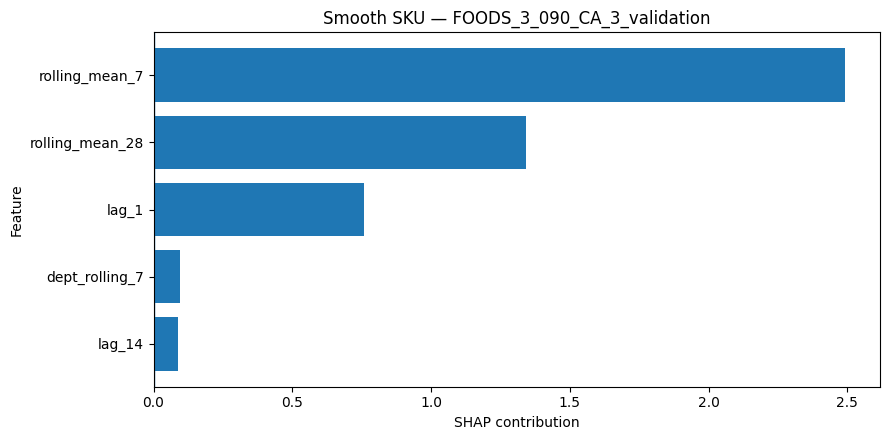

── Erratic representative ──
SKU: HOBBIES_1_234_CA_3_validation
Snapshot date: 2016-01-31 00:00:00



,Rank,Feature,Feature Value,Missing?,SHAP,Direction
27465,1,rolling_mean_7,14.0000,False,1.3525,positive
27466,2,rolling_mean_28,24.8929,False,1.2855,positive
27467,3,sell_price,0.3000,False,0.6125,positive
27468,4,lag_1,0.0000,False,-0.4901,negative
27469,5,rolling_std_7,24.4199,False,-0.3419,negative


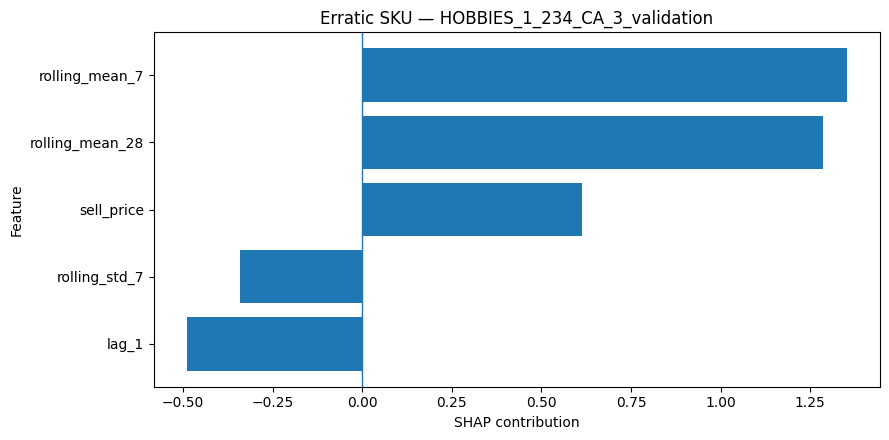

── Representative routing SKUs ──
Intermittent: FOODS_1_001_WI_2_validation
Lumpy       : FOODS_1_001_WI_3_validation

── Four-regime explainability summary ──


,Regime,Representative SKU,Forecast Method,Inventory Method,Explanation Type,Explanation
0,Smooth,FOODS_3_090_CA_3_validation,LightGBM Tweedie,Dynamic policy,SHAP,Top-5 predictive feature contributions
1,Erratic,HOBBIES_1_234_CA_3_validation,LightGBM Tweedie,Dynamic policy,SHAP,Top-5 predictive feature contributions
2,Intermittent,FOODS_1_001_WI_2_validation,TSB,Dynamic policy,Routing,Intermittent-demand routing to TSB
3,Lumpy,FOODS_1_001_WI_3_validation,Historical policy,Historical demand policy,Routing,Lumpy-demand routing to historical policy



── Representative Tweedie SHAP comparison ──


,Regime,Rank,Feature,SHAP,Direction
0,Smooth,1,rolling_mean_7,2.4932,positive
1,Smooth,2,rolling_mean_28,1.3417,positive
2,Smooth,3,lag_1,0.7597,positive
3,Smooth,4,dept_rolling_7,0.0942,positive
4,Smooth,5,lag_14,0.0896,positive
5,Erratic,1,rolling_mean_7,1.3525,positive
6,Erratic,2,rolling_mean_28,1.2855,positive
7,Erratic,3,sell_price,0.6125,positive
8,Erratic,4,lag_1,-0.4901,negative
9,Erratic,5,rolling_std_7,-0.3419,negative



Saved: ../data/processed/predictions/explainability/representative_explainability_fold3.parquet

✓ Section 5 complete.
✓ Smooth and Erratic representative SHAP explanations generated.
✓ Intermittent and Lumpy routing explanations generated.
✓ No model retraining or modification performed.


In [12]:
# -- 08 Section 5: Representative Explainability Cases -------------------------------
# Demonstrates the frozen Fold 3 decision system across all four demand regimes.
# Smooth/Erratic: individual SHAP explanations.
# Intermittent/Lumpy: routing and policy explanations.
# No retraining, tuning, or model changes.

print('=' * 88)
print('SECTION 5: REPRESENTATIVE EXPLAINABILITY CASES')
print('=' * 88)
print()

# ── Required state ----------------------------------------------------------------------

assert 'SHAP_DIR' in globals()
assert 'sku_regimes_fold3' in globals()

# ── Load Section 4 artifact from disk ---------------------------------------------------

sku_shap_path = (
    f'{SHAP_DIR}/shap_per_sku_fold3.parquet'
)

shap_per_sku = pd.read_parquet(
    sku_shap_path
)

print(
    f'Loaded per-SKU SHAP artifact: {sku_shap_path}'
)
print(
    f'Rows: {len(shap_per_sku):,}'
)
print(
    f'SKUs: {shap_per_sku["id"].nunique():,}'
)
print()

# ── Basic validation ---------------------------------------------------------------------

assert {
    'id',
    'date',
    'regime',
    'feature',
    'feature_value',
    'shap_value',
    'abs_shap',
    'direction',
    'rank'
}.issubset(shap_per_sku.columns), (
    'Section 4 SHAP artifact is missing one or more required columns.'
)

assert (
    shap_per_sku['rank']
    .between(1, 5)
    .all()
), (
    'Unexpected SHAP rank detected.'
)

assert np.isfinite(
    shap_per_sku['shap_value']
).all(), (
    'Non-finite SHAP contribution detected.'
)

# ── Regime summary -----------------------------------------------------------------------

print('── Fold 3 regime population ──')

regime_summary = (
    sku_regimes_fold3[
        ['id', 'regime']
    ]
    .drop_duplicates('id')
    ['regime']
    .value_counts()
    .rename_axis('Regime')
    .reset_index(name='SKUs')
)

regime_summary['Share'] = (
    regime_summary['SKUs']
    / regime_summary['SKUs'].sum()
)

display(
    regime_summary.assign(
        Share=regime_summary['Share'].map(
            lambda x: f'{x:.1%}'
        )
    )
)

print()

# ── 5.1 Select representative Smooth / Erratic SKUs -------------------------------

# Select the SKU with the largest total absolute SHAP contribution
# within each Tweedie regime. This gives a visually informative example.
#
# This selection is purely for demonstration and is NOT a model evaluation metric.

sku_explanation_strength = (
    shap_per_sku
    .groupby(
        ['id', 'regime'],
        observed=True
    )
    .agg(
        total_abs_shap=('abs_shap', 'sum'),
        max_abs_shap=('abs_shap', 'max')
    )
    .reset_index()
)

tweedie_representatives = {}

for regime in ['smooth', 'erratic']:

    candidates = (
        sku_explanation_strength[
            sku_explanation_strength['regime'] == regime
        ]
        .sort_values(
            [
                'total_abs_shap',
                'max_abs_shap',
                'id'
            ],
            ascending=[
                False,
                False,
                True
            ]
        )
    )

    assert len(candidates) > 0, (
        f'No {regime} SHAP examples found.'
    )

    tweedie_representatives[regime] = (
        candidates.iloc[0]['id']
    )

print('── Representative Tweedie SKUs ──')

for regime, sku_id in tweedie_representatives.items():

    print(
        f'{regime.title():8s}: {sku_id}'
    )

print()

# ── 5.2 Display + plot top-5 SHAP for representative SKU ----------------------------

def show_sku_explanation(
    shap_df,
    sku_id,
    regime,
    top_n=5
):
    """
    Display and plot the top-N SHAP contributors for one SKU.
    """

    df = (
        shap_df[
            shap_df['id'] == sku_id
        ]
        .sort_values(
            'abs_shap',
            ascending=False
        )
        .head(top_n)
        .copy()
    )

    assert len(df) == top_n, (
        f'Expected {top_n} SHAP rows for {sku_id}, '
        f'got {len(df)}.'
    )

    print(
        f'── {regime.title()} representative ──'
    )
    print(
        f'SKU: {sku_id}'
    )
    print(
        f'Snapshot date: {df["date"].iloc[0]}'
    )
    print()

    display(
        df[
            [
                'rank',
                'feature',
                'feature_value',
                'feature_value_missing',
                'shap_value',
                'direction'
            ]
        ]
        .rename(
            columns={
                'rank': 'Rank',
                'feature': 'Feature',
                'feature_value': 'Feature Value',
                'feature_value_missing': 'Missing?',
                'shap_value': 'SHAP',
                'direction': 'Direction'
            }
        )
        .round(
            {
                'Feature Value': 4,
                'SHAP': 4
            }
        )
    )

    # Sort from most negative to most positive for the chart.
    plot_df = (
        df
        .sort_values(
            'shap_value',
            ascending=True
        )
    )

    fig, ax = plt.subplots(
        figsize=(9, 4.5)
    )

    ax.barh(
        plot_df['feature'],
        plot_df['shap_value']
    )

    ax.axvline(
        0,
        linewidth=1
    )

    ax.set_title(
        f'{regime.title()} SKU — {sku_id}'
    )

    ax.set_xlabel(
        'SHAP contribution'
    )

    ax.set_ylabel(
        'Feature'
    )

    plt.tight_layout()
    plt.show()

    return df


smooth_top5 = show_sku_explanation(
    shap_df=shap_per_sku,
    sku_id=tweedie_representatives['smooth'],
    regime='smooth'
)

erratic_top5 = show_sku_explanation(
    shap_df=shap_per_sku,
    sku_id=tweedie_representatives['erratic'],
    regime='erratic'
)

# ── 5.3 Select representative Intermittent / Lumpy SKUs ----------------------------

# These regimes do not use the Tweedie model, so no SHAP explanation is created.
# Select deterministic examples from the frozen regime assignments.

routing_representatives = {}

for regime in ['intermittent', 'lumpy']:

    candidates = (
        sku_regimes_fold3[
            sku_regimes_fold3['regime'] == regime
        ]
        [['id', 'regime']]
        .drop_duplicates('id')
        .sort_values('id')
    )

    assert len(candidates) > 0, (
        f'No {regime} SKUs found.'
    )

    routing_representatives[regime] = (
        candidates.iloc[0]['id']
    )

print('── Representative routing SKUs ──')

for regime, sku_id in routing_representatives.items():

    print(
        f'{regime.title():12s}: {sku_id}'
    )

print()

# ── 5.4 Build four-regime explanation summary --------------------------------------

representative_cases = pd.DataFrame(
    [
        {
            'Regime': 'Smooth',
            'Representative SKU': (
                tweedie_representatives['smooth']
            ),
            'Forecast Method': 'LightGBM Tweedie',
            'Inventory Method': 'Dynamic policy',
            'Explanation Type': 'SHAP',
            'Explanation':
                'Top-5 predictive feature contributions'
        },
        {
            'Regime': 'Erratic',
            'Representative SKU': (
                tweedie_representatives['erratic']
            ),
            'Forecast Method': 'LightGBM Tweedie',
            'Inventory Method': 'Dynamic policy',
            'Explanation Type': 'SHAP',
            'Explanation':
                'Top-5 predictive feature contributions'
        },
        {
            'Regime': 'Intermittent',
            'Representative SKU': (
                routing_representatives['intermittent']
            ),
            'Forecast Method': 'TSB',
            'Inventory Method': 'Dynamic policy',
            'Explanation Type': 'Routing',
            'Explanation':
                'Intermittent-demand routing to TSB'
        },
        {
            'Regime': 'Lumpy',
            'Representative SKU': (
                routing_representatives['lumpy']
            ),
            'Forecast Method': 'Historical policy',
            'Inventory Method': 'Historical demand policy',
            'Explanation Type': 'Routing',
            'Explanation':
                'Lumpy-demand routing to historical policy'
        }
    ]
)

print('── Four-regime explainability summary ──')

display(
    representative_cases
)

print()

# ── 5.5 Compact SHAP comparison ---------------------------------------------------------

print('── Representative Tweedie SHAP comparison ──')

shap_comparison = pd.concat(
    [
        (
            smooth_top5
            .assign(
                Regime='Smooth'
            )
        ),
        (
            erratic_top5
            .assign(
                Regime='Erratic'
            )
        )
    ],
    ignore_index=True
)

display(
    shap_comparison[
        [
            'Regime',
            'rank',
            'feature',
            'shap_value',
            'direction'
        ]
    ]
    .rename(
        columns={
            'Regime': 'Regime',
            'rank': 'Rank',
            'feature': 'Feature',
            'shap_value': 'SHAP',
            'direction': 'Direction'
        }
    )
    .round(
        {
            'SHAP': 4
        }
    )
)

print()

# ── 5.6 Save representative case metadata ---------------------------------------------

representative_output = (
    f'{SHAP_DIR}/representative_explainability_fold3.parquet'
)

representative_cases.to_parquet(
    representative_output,
    index=False
)

print(
    f'Saved: {representative_output}'
)

print()
print('✓ Section 5 complete.')
print('✓ Smooth and Erratic representative SHAP explanations generated.')
print('✓ Intermittent and Lumpy routing explanations generated.')
print('✓ No model retraining or modification performed.')

### Results

The four representative cases demonstrate how the frozen decision system handles each demand regime.

| Regime       | Representative SKU   | Forecast Method   | Explanation                          |
| ------------ | -------------------- | ----------------- | ------------------------------------ |
| Smooth       | `FOODS_3_090_CA_3`   | LightGBM Tweedie  | Top-5 SHAP contributions             |
| Erratic      | `HOBBIES_1_234_CA_3` | LightGBM Tweedie  | Top-5 SHAP contributions             |
| Intermittent | `FOODS_1_001_WI_2`   | TSB               | Routing to intermittent-demand model |
| Lumpy        | `FOODS_1_001_WI_3`   | Historical policy | Routing to historical-demand policy  |

The representative Tweedie explanations were taken from the final Fold 3 validation snapshot on **2016-01-31**.

### Smooth example

| Rank | Feature           |    Value |    SHAP | Direction |
| ---: | ----------------- | -------: | ------: | --------- |
|    1 | `rolling_mean_7`  |    92.43 | +2.4932 | Positive  |
|    2 | `rolling_mean_28` |    81.46 | +1.3417 | Positive  |
|    3 | `lag_1`           |   113.00 | +0.7597 | Positive  |
|    4 | `dept_rolling_7`  | 2,722.86 | +0.0942 | Positive  |
|    5 | `lag_14`          |   106.00 | +0.0896 | Positive  |

For this Smooth SKU, the prediction is driven primarily by recent demand levels. The 7-day rolling mean contributes the most, followed by the 28-day rolling mean and most recent observed demand.

### Erratic example

| Rank | Feature           | Value |    SHAP | Direction |
| ---: | ----------------- | ----: | ------: | --------- |
|    1 | `rolling_mean_7`  | 14.00 | +1.3525 | Positive  |
|    2 | `rolling_mean_28` | 24.89 | +1.2855 | Positive  |
|    3 | `sell_price`      |  0.30 | +0.6125 | Positive  |
|    4 | `lag_1`           |  0.00 | -0.4901 | Negative  |
|    5 | `rolling_std_7`   | 24.42 | -0.3419 | Negative  |

The Erratic example is also dominated by recent demand history, but price and short-term volatility have materially larger individual contributions than in the Smooth example.

### Cross-case interpretation

| Feature pattern   |    Smooth | Erratic |
| ----------------- | --------: | ------: |
| `rolling_mean_7`  |   +2.4932 | +1.3525 |
| `rolling_mean_28` |   +1.3417 | +1.2855 |
| `lag_1`           |   +0.7597 | -0.4901 |
| `sell_price`      | Not top 5 | +0.6125 |
| `rolling_std_7`   | Not top 5 | -0.3419 |

Both examples reinforce the global SHAP result: **recent demand level is the dominant predictive signal**. The individual explanation also varies by SKU, with price and short-term volatility becoming more influential for the Erratic example.

The Intermittent and Lumpy examples demonstrate a different form of explainability: rather than explaining a Tweedie prediction, the system explains **which forecasting path the SKU was routed into and why that path differs from the Tweedie model**.

The representative cases are saved to `representative_explainability_fold3.parquet`.
::


## Section 6 — Explainability QA

This section performs the final audit of the Fold 3 explainability artifacts.

The checks verify:

* SHAP reconstruction against the frozen model's native prediction scale
* one explanation snapshot for every Tweedie-routed SKU
* exactly five ranked contributors per SKU
* finite SHAP values
* valid SHAP directions and ranks
* consistency between the saved SHAP artifact and frozen regime assignments
* completeness of the representative explainability artifact

No model, feature pipeline, or routing decision is modified by these checks.


In [13]:
# -- 08 Section 6: Explainability QA ----------------------------------------------------
# Final audit of Notebook 08 explainability artifacts.
# No retraining, tuning, or model modification.

print('=' * 88)
print('SECTION 6: EXPLAINABILITY QA')
print('=' * 88)
print()

# ── Required state ----------------------------------------------------------------------

assert 'SHAP_DIR' in globals()
assert 'FEATURE_COLS' in globals()
assert 'model_tweedie_fold3' in globals()
assert 'sku_regimes_fold3' in globals()

# ── Load saved Section 4 / 5 artifacts -------------------------------------------------

sku_shap_path = (
    f'{SHAP_DIR}/shap_per_sku_fold3.parquet'
)

representative_path = (
    f'{SHAP_DIR}/representative_explainability_fold3.parquet'
)

shap_per_sku_qa = pd.read_parquet(
    sku_shap_path
)

representative_cases_qa = pd.read_parquet(
    representative_path
)

print(
    f'Loaded SHAP artifact: {sku_shap_path}'
)
print(
    f'Loaded representative artifact: {representative_path}'
)
print()

# ── QA 1: SHAP artifact structure ------------------------------------------------------

required_shap_columns = {
    'id',
    'date',
    'regime',
    'feature',
    'feature_value',
    'feature_value_missing',
    'shap_value',
    'abs_shap',
    'direction',
    'rank'
}

missing_columns = (
    required_shap_columns
    - set(shap_per_sku_qa.columns)
)

assert not missing_columns, (
    f'Missing SHAP columns: {sorted(missing_columns)}'
)

print('✓ Required SHAP columns present')

# ── QA 2: SKU coverage -----------------------------------------------------------------

tweedie_ids = set(
    sku_regimes_fold3.loc[
        sku_regimes_fold3['regime'].isin(
            ['smooth', 'erratic']
        ),
        'id'
    ]
)

shap_ids = set(
    shap_per_sku_qa['id'].unique()
)

missing_skus = tweedie_ids - shap_ids
unexpected_skus = shap_ids - tweedie_ids

assert not missing_skus, (
    f'Missing SHAP explanations for '
    f'{len(missing_skus):,} Tweedie SKUs.'
)

assert not unexpected_skus, (
    f'SHAP artifact contains '
    f'{len(unexpected_skus):,} non-Tweedie SKUs.'
)

assert len(shap_ids) == len(tweedie_ids), (
    'SHAP SKU coverage does not match the frozen Tweedie population.'
)

print(
    f'✓ SKU coverage complete: {len(shap_ids):,}/{len(tweedie_ids):,}'
)

# ── QA 3: Exactly five explanations per SKU -------------------------------------------

rows_per_sku = (
    shap_per_sku_qa
    .groupby('id', observed=True)
    .size()
)

assert rows_per_sku.eq(5).all(), (
    'Every SKU must have exactly five SHAP rows.'
)

print(
    '✓ Exactly 5 SHAP rows per SKU'
)

# ── QA 4: Rank integrity ----------------------------------------------------------------

rank_sets = (
    shap_per_sku_qa
    .groupby('id', observed=True)['rank']
    .apply(set)
)

assert rank_sets.apply(
    lambda x: x == {1, 2, 3, 4, 5}
).all(), (
    'Every SKU must contain ranks 1 through 5 exactly once.'
)

print(
    '✓ Rank integrity: every SKU has ranks 1–5'
)

# ── QA 5: Feature uniqueness ------------------------------------------------------------

feature_counts = (
    shap_per_sku_qa
    .groupby('id', observed=True)['feature']
    .nunique()
)

assert feature_counts.eq(5).all(), (
    'Duplicate features detected within at least one SKU explanation.'
)

print(
    '✓ Five unique features per SKU'
)

# ── QA 6: SHAP numerical validity ------------------------------------------------------

assert np.isfinite(
    shap_per_sku_qa['shap_value']
).all(), (
    'Non-finite SHAP values detected.'
)

assert np.isfinite(
    shap_per_sku_qa['abs_shap']
).all(), (
    'Non-finite absolute SHAP values detected.'
)

# abs_shap must equal abs(shap_value)
assert np.allclose(
    shap_per_sku_qa['abs_shap'].to_numpy(),
    np.abs(shap_per_sku_qa['shap_value'].to_numpy()),
    rtol=1e-10,
    atol=1e-12
), (
    'abs_shap does not match abs(shap_value).'
)

print(
    '✓ All SHAP values finite'
)
print(
    '✓ abs_shap matches |shap_value|'
)

# ── QA 7: Direction integrity -----------------------------------------------------------

expected_direction = np.where(
    shap_per_sku_qa['shap_value'].to_numpy() > 0,
    'positive',
    np.where(
        shap_per_sku_qa['shap_value'].to_numpy() < 0,
        'negative',
        'neutral'
    )
)

assert np.array_equal(
    expected_direction,
    shap_per_sku_qa['direction'].to_numpy()
), (
    'SHAP direction labels do not match SHAP signs.'
)

assert (
    shap_per_sku_qa['direction']
    .isin(
        [
            'positive',
            'negative',
            'neutral'
        ]
    )
    .all()
)

print(
    '✓ SHAP direction labels are consistent with SHAP signs'
)

# ── QA 8: Frozen regime consistency ----------------------------------------------------

regime_lookup = (
    sku_regimes_fold3
    .set_index('id')['regime']
)

artifact_regimes = (
    shap_per_sku_qa['id']
    .map(regime_lookup)
)

assert artifact_regimes.notna().all(), (
    'At least one SHAP SKU is missing a frozen regime assignment.'
)

assert (
    artifact_regimes.to_numpy()
    == shap_per_sku_qa['regime'].to_numpy()
).all(), (
    'SHAP regime labels do not match frozen Fold 3 assignments.'
)

print(
    '✓ SHAP regime labels match frozen Fold 3 assignments'
)

# ── QA 9: Feature names belong to frozen model -----------------------------------------

unknown_features = (
    set(shap_per_sku_qa['feature'].unique())
    - set(FEATURE_COLS)
)

assert not unknown_features, (
    f'Unknown features detected: {sorted(unknown_features)}'
)

print(
    '✓ All explained features belong to frozen feature set'
)

# ── QA 10: Representative artifact ----------------------------------------------------

expected_regimes = {
    'Smooth',
    'Erratic',
    'Intermittent',
    'Lumpy'
}

assert set(
    representative_cases_qa['Regime']
) == expected_regimes, (
    'Representative artifact does not contain exactly the four demand regimes.'
)

assert (
    representative_cases_qa['Representative SKU']
    .nunique()
    == 4
), (
    'Representative cases must contain four distinct SKUs.'
)

print(
    '✓ Representative artifact contains one case per demand regime'
)

# ── QA 11: Representative SHAP cases actually exist -------------------------------

shap_representative_cases = representative_cases_qa[
    representative_cases_qa['Explanation Type'] == 'SHAP'
]

for sku_id in shap_representative_cases['Representative SKU']:

    assert (
        sku_id in shap_ids
    ), (
        f'Representative SHAP SKU missing from SHAP artifact: {sku_id}'
    )

    assert (
        len(
            shap_per_sku_qa[
                shap_per_sku_qa['id'] == sku_id
            ]
        ) == 5
    ), (
        f'Representative SKU does not have five SHAP rows: {sku_id}'
    )

print(
    '✓ Representative SHAP cases exist in saved artifact'
)

# ── QA summary ----------------------------------------------------------------------------

qa_results = pd.DataFrame(
    [
        {
            'Check': 'Required SHAP columns',
            'Result': 'PASS',
            'Detail': f'{len(required_shap_columns)} required columns present'
        },
        {
            'Check': 'Tweedie SKU coverage',
            'Result': 'PASS',
            'Detail': f'{len(shap_ids):,} / {len(tweedie_ids):,} SKUs'
        },
        {
            'Check': 'Rows per SKU',
            'Result': 'PASS',
            'Detail': 'Exactly 5'
        },
        {
            'Check': 'Rank integrity',
            'Result': 'PASS',
            'Detail': 'Ranks 1–5'
        },
        {
            'Check': 'Feature uniqueness',
            'Result': 'PASS',
            'Detail': '5 unique features per SKU'
        },
        {
            'Check': 'SHAP finite values',
            'Result': 'PASS',
            'Detail': 'All finite'
        },
        {
            'Check': 'SHAP magnitude integrity',
            'Result': 'PASS',
            'Detail': 'abs_shap = |shap_value|'
        },
        {
            'Check': 'Direction integrity',
            'Result': 'PASS',
            'Detail': 'Labels match SHAP signs'
        },
        {
            'Check': 'Regime consistency',
            'Result': 'PASS',
            'Detail': 'Matches frozen Fold 3 assignments'
        },
        {
            'Check': 'Feature-set consistency',
            'Result': 'PASS',
            'Detail': 'All features in frozen 39-feature set'
        },
        {
            'Check': 'Representative coverage',
            'Result': 'PASS',
            'Detail': 'Smooth / Erratic / Intermittent / Lumpy'
        }
    ]
)

print()
print('── Explainability QA summary ──')

display(
    qa_results
)

# ── Save QA report ----------------------------------------------------------------------

qa_report_path = (
    f'{SHAP_DIR}/shap_validation_report.json'
)

qa_report = {
    'status': 'PASS',
    'tweedie_skus': int(len(tweedie_ids)),
    'shap_skus': int(len(shap_ids)),
    'shap_rows': int(len(shap_per_sku_qa)),
    'features_per_sku': 5,
    'frozen_feature_count': int(len(FEATURE_COLS)),
    'representative_regimes': sorted(
        expected_regimes
    )
}

import json

with open(
    qa_report_path,
    'w',
    encoding='utf-8'
) as f:
    json.dump(
        qa_report,
        f,
        indent=2
    )

print()
print(
    f'Saved QA report: {qa_report_path}'
)

print()
print('✓ Section 6 complete.')
print('✓ Explainability artifacts passed structural and consistency QA.')
print('✓ No model, feature pipeline, or routing logic modified.')

SECTION 6: EXPLAINABILITY QA

Loaded SHAP artifact: ../data/processed/predictions/explainability/shap_per_sku_fold3.parquet
Loaded representative artifact: ../data/processed/predictions/explainability/representative_explainability_fold3.parquet

✓ Required SHAP columns present
✓ SKU coverage complete: 9,017/9,017
✓ Exactly 5 SHAP rows per SKU
✓ Rank integrity: every SKU has ranks 1–5
✓ Five unique features per SKU
✓ All SHAP values finite
✓ abs_shap matches |shap_value|
✓ SHAP direction labels are consistent with SHAP signs
✓ SHAP regime labels match frozen Fold 3 assignments
✓ All explained features belong to frozen feature set
✓ Representative artifact contains one case per demand regime
✓ Representative SHAP cases exist in saved artifact

── Explainability QA summary ──


,Check,Result,Detail
0,Required SHAP columns,PASS,10 required columns present
1,Tweedie SKU coverage,PASS,"9,017 / 9,017 SKUs"
2,Rows per SKU,PASS,Exactly 5
3,Rank integrity,PASS,Ranks 1–5
4,Feature uniqueness,PASS,5 unique features per SKU
5,SHAP finite values,PASS,All finite
6,SHAP magnitude integrity,PASS,abs_shap = |shap_value|
7,Direction integrity,PASS,Labels match SHAP signs
8,Regime consistency,PASS,Matches frozen Fold 3 assignments
9,Feature-set consistency,PASS,All features in frozen 39-feature set



Saved QA report: ../data/processed/predictions/explainability/shap_validation_report.json

✓ Section 6 complete.
✓ Explainability artifacts passed structural and consistency QA.
✓ No model, feature pipeline, or routing logic modified.


### Results

All explainability QA checks passed.

| Check                       | Result        |
| --------------------------- | ------------- |
| Tweedie SKU coverage        | 9,017 / 9,017 |
| SHAP records                | 45,085        |
| Contributors per SKU        | Exactly 5     |
| Rank integrity              | PASS          |
| Feature uniqueness          | PASS          |
| SHAP values finite          | PASS          |
| `abs_shap = \|shap_value\|` | PASS          |
| Direction labels            | PASS          |
| Regime consistency          | PASS          |
| Feature-set consistency     | PASS          |
| Representative coverage     | 4 / 4 regimes |

The final explainability artifacts are therefore suitable for downstream portfolio/app use without modifying the frozen Fold 3 model.

Saved artifacts:

* `shap_per_sku_fold3.parquet` — top-5 SHAP explanations for all 9,017 Tweedie-routed SKUs
* `representative_explainability_fold3.parquet` — representative cases across all four regimes
* `shap_validation_report.json` — final explainability QA report

No model, feature pipeline, or routing logic was changed during Notebook 08.
